# RFM-анализ клиентской базы аптечной сети

### Цель проекта

В условиях сезонного снижения выручки аптечная сеть хочет выделить клиентские сегменты и использовать SMS-рассылки для стимулирования повторных покупок и роста выручки.

### Цели исследования

- выделить клиентские сегменты по поведению покупателей;
- определить, какие сегменты приносят основную выручку;
- предложить практические рекомендации по удержанию и реактивации клиентов.

### Бизнес-контекст

Проект помогает понять, какие клиенты приносят основную выручку, кого важно удерживать в первую очередь и какие сегменты можно возвращать недорогими коммуникациями.

### Структура данных

Для анализа использовалась таблица транзакций по бонусным картам. В работу включались только те покупки, где клиент мог быть идентифицирован по карте. Это важно, потому что офлайн-операции без привязки к карте не дают возможности корректно оценить поведение клиента.

**Таблица включает в себя следующие столбцы:**

- `datetime` - дата и время совершения транзакции
- `shop` - наименование аптеки
- `card` - номер карты
- `bonus_earned` - количество полученных бонусов
- `bonus_spent` - количество списанных бонусов
- `summ` - итоговая сумма чека
- `doc_id` - номер документа

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

### Подключение к данным

In [2]:
load_dotenv()

DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:"
    f"{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:"
    f"{os.getenv('DB_PORT')}/"
    f"{os.getenv('DB_NAME')}"
)

engine = create_engine(DATABASE_URL)

Для дальнейшего удобства сразу напишем настройки для графиков и вспомогательные методы

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [17]:
def plot_rfm_share(
    df,
    segment_col,
    customer_share_col,
    revenue_share_col,
    xlabel,
    ylabel,
    ax1label,
    ax2label,
    title
):

    fig, ax1 = plt.subplots()

    bars = ax1.bar(
        df[segment_col],
        df[customer_share_col],
        width=0.6,
        color="tab:blue",
        alpha=0.8,
        label=ax1label
    )

    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel, color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax1.bar_label(
        bars,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

    ax1.grid(axis="y", linestyle="--", alpha=0.4)

    ax2 = ax1.twinx()

    ax2.plot(
        df[segment_col],
        df[revenue_share_col],
        color="tab:orange",
        marker="o",
        linewidth=3,
        markersize=7,
        label=ax2label
    )

    ax2.set_ylabel(ax2label, color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    for x, y in zip(df[segment_col], df[revenue_share_col]):
        ax2.annotate(
            f"{y:.1f}%",
            xy=(x, y),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc="upper right",
        frameon=False
    )

    ax1.set_title(
        title,
        pad=15
    )

    plt.tight_layout()
    plt.show()

In [5]:
def draw_bar(df, x_col, y_col, title, xlabel, ylabel, format_labels=None):
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=x_col,
        palette="deep",
        legend=False
    )
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=35, ha="right")

    for container in ax.containers:
        if format_labels == "currency":
            labels = [f"{value:,.0f}" for value in container.datavalues]
        else:
            labels = [f"{value:,.0f}" for value in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=10)

    plt.tight_layout()
    plt.show()

In [6]:
def read_sql_from_file(filename):
    query = Path(f"sql/{filename}.sql").read_text(encoding="utf-8")
    return pd.read_sql(text(query), engine)

### RFM-сегментация клиентов

RFM-анализ позволяет разделить клиентов по трем измерениям: давности последней покупки, частоте покупок и сумме трат. 

Посмотрим, как распределяются клиенты по сегментам и какую долю выручки каждый сегмент формирует.

In [20]:
rfm_df = read_sql_from_file("rfm_segmentation")
rfm_df_sorted = rfm_df.sort_values(by="revenue_share_pct", ascending=False)
rfm_df_sorted

,segment,customers,total_customers,total_revenue_per_segment,avg_revenue_per_customer,customer_share_pct,revenue_share_pct
2,Чемпионы,964,5926.0,10371849.0,10759.18,16.27,54.03
0,Лояльные,2135,5926.0,6240110.0,2922.77,36.03,32.51
3,Под угрозой,849,5926.0,1027741.0,1210.53,14.33,5.35
4,Нельзя терять,802,5926.0,854217.0,1065.11,13.53,4.45
1,Потерянные,1176,5926.0,702923.0,597.72,19.84,3.66


Каждый сегмент описывает количество клиентов и вклад в выручку. 

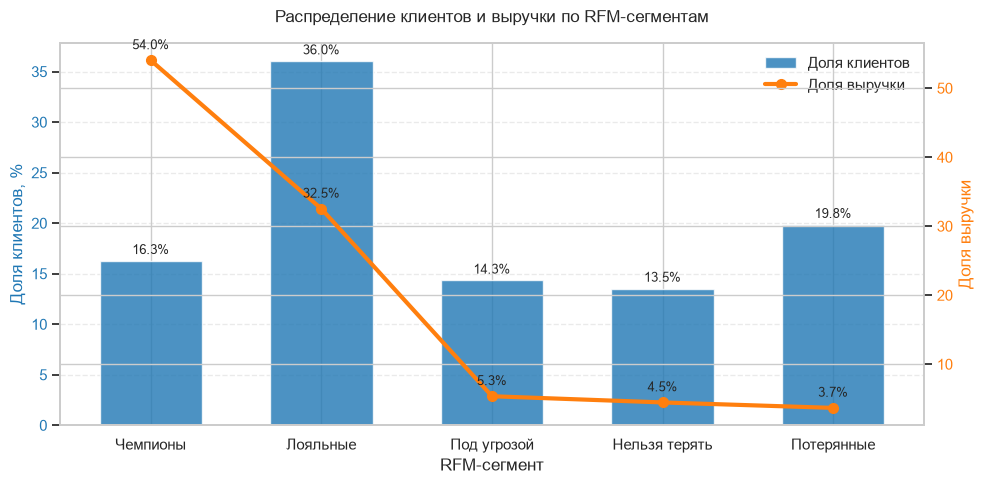

In [21]:
plot_rfm_share(
    df=rfm_df_sorted,
    segment_col="segment",
    customer_share_col="customer_share_pct",
    revenue_share_col="revenue_share_pct",
    xlabel="RFM-сегмент",
    ylabel="Доля клиентов, %",
    ax1label="Доля клиентов",
    ax2label="Доля выручки",
    title="Распределение клиентов и выручки по RFM-сегментам"
)

##### Вывод
Основную ценность формируют сегменты `Чемпионы` и `Лояльные` вместе они составляют **52,3%** клиентской базы и генерируют **86,5%** всей выручки.

#### ABC-анализ: где концентрируется выручка

ABC-анализ помогает понять, какие клиенты приносят 80% и 95% выручки, и как они распределены по RFM-сегментам.

In [9]:
abc_rfm_df = read_sql_from_file("abc_revenue")
abc_rfm_df = abc_rfm_df[["card", "segment", "abc_revenue", "total_revenue", "cum_revenue_pct"]]
abc_rfm_df.head()

,card,segment,abc_revenue,total_revenue,cum_revenue_pct
0,2000200170860,Чемпионы,A,163943,0.85
1,2000200196556,Чемпионы,A,122941,1.49
2,2000200196600,Чемпионы,A,120782,2.12
3,2000200189985,Чемпионы,A,112173,2.71
4,2000200204541,Чемпионы,A,102314,3.24


In [10]:
abc_summary = (
    abc_rfm_df.groupby('abc_revenue')
    .agg(customers=('card', 'count'), revenue=('total_revenue', 'sum'))
    .reset_index()
)

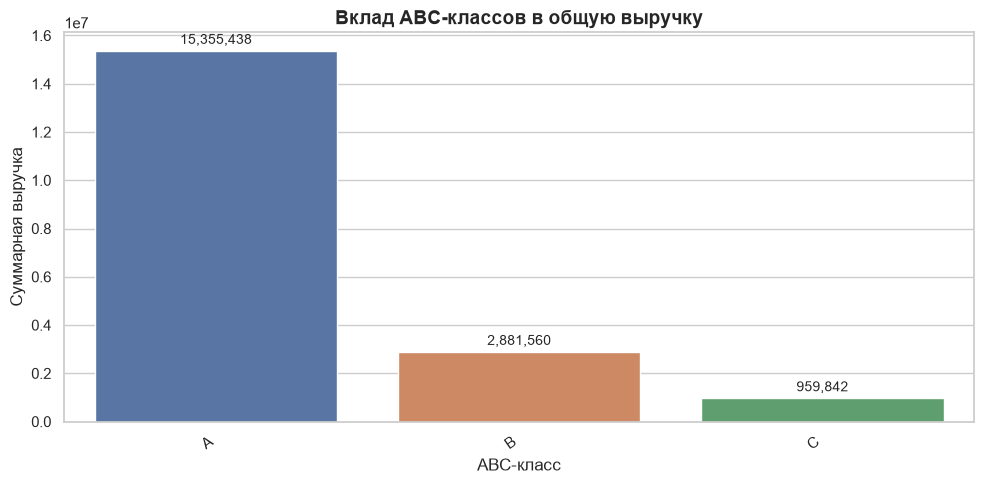

In [11]:
draw_bar(
    abc_summary,
    x_col='abc_revenue',
    y_col='revenue',
    title='Вклад ABC-классов в общую выручку',
    xlabel='ABC-класс',
    ylabel='Суммарная выручка',
    format_labels='currency'
)

#### Вывод

- Класс `A` генерирует основную долю выручки. Его стоит рассматривать как пул наиболее важных клиентов.
- Класс `B` — резерв для роста выгодно усиливать конверсии и двигать часть из них в `A`.
- Класс `C` подходит для экономичных тестовых кампаний, но вкладывать туда большие бюджеты не стоит.

### Распределение клиентов по RFM-сегментам и ABC-классам

Посмотрим, как RFM-сегменты распределяются внутри ABC-классов. Это позволяет увидеть, где теряются дорогие клиенты.

In [12]:
rfm_abc = (
    abc_rfm_df.groupby(['segment', 'abc_revenue'])
    .agg(customers=('card', 'count'))
    .reset_index()
)

pivot = rfm_abc.pivot(index='segment', columns='abc_revenue', values='customers').fillna(0)

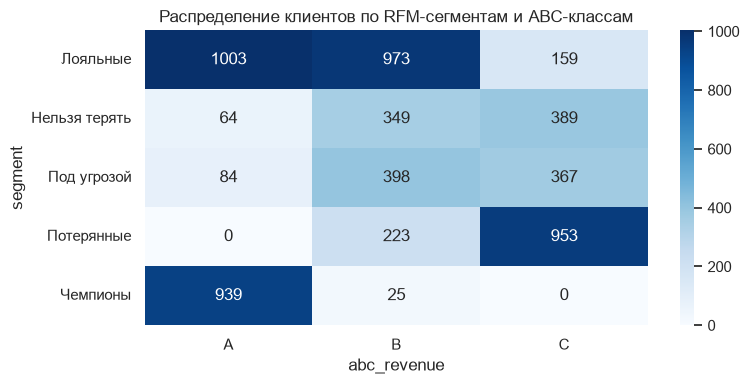

In [13]:
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Распределение клиентов по RFM-сегментам и ABC-классам')
plt.tight_layout()
plt.show()

#### Вывод

1. Более 1900 клиентов (сегменты 'Лояльные' и 'Чемпионы' класса А) являются опорой бизнеса.
2. 84 клиента в категории Под угрозой' класса А. Потеря хотя бы 30% из них скажется на выручке. 
3. 25 клиентов из 'Чемпионов' в классе В идеальная группа для апселлинга, так как они уже активны, но не добирают по сумме.
4. Категория 'Потерянные' класса С насчитывает 953 клиента, а также значительное количество в классе В.

## Рекомендации по сегментам

| Сегмент | ABC-класс | Приоритет | Рекомендация |
| --- | --- | --- | --- |
| Чемпионы | A | Удержание | Персональные условия, VIP-предложения, бонусы за повторные покупки и ранний доступ к новинкам. |
| Лояльные | A/B | Развитие | Кросс-продажи, рекомендации по смежным товарам и программы для роста среднего чека. |
| Под угрозой | A/B | Реактивация | Целевые бонусы, напоминания о повторной покупке и персонализированные предложения для возврата в активное состояние. |
| Нельзя терять | A | Приоритетная win-back | Индивидуальные коммуникации, специальные условия и быстрый контакт с клиентом для предотвращения потери выручки. |
| Потерянные | B/C | Тестирование | Низкобюджетные win-back кампании с осторожным подходом и оценкой эффективности. |

**Ключевая мысль:** не все сегменты требуют одинакового уровня внимания. Наиболее ценные клиенты должны получать более сильные и персонализированные коммуникации, а менее активные — более осторожные и экономичные действия.